# Multivariate Hybrid LSTM for Daily BTC-USD Price Prediction Using Quantitative Market Data Features

## Installing Libraries and Modules

In [1]:
%pip install yfinance pandas numpy matplotlib scikit-learn torch torchvision torchaudio transformers backtrader 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys 
import yfinance as yf 
import pandas as pd 
from sklearn import preprocessing 
import numpy as np 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
import math 
from torch.utils.data import TensorDataset 
from torch.utils.data import DataLoader 
import torch.optim as optim 
import time 
import os 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
import random
%matplotlib inline
import matplotlib.pyplot as plt 

In [3]:
def set_seed(seed=70):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # For GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if multi-GPU

    # Ensures reproducibility on GPU (slightly slower)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set your seed here
set_seed(48)

# TRIAL 62 - SEED 55
# TRIAL 53 - SEED 48 # CURRENT RUN!!!
# TRIAL 70 - OPTUNA WITH LOG RETURN, LN and ATTN

## Fetching Historical BTC-USDT Price Data

In [4]:
# Download the last 5 years of BTC-USDT Price data (Daily) from Yahoo Finance
df = yf.download(
    "BTC-USD",
    start = "2015-01-01",
    end = "2024-01-01",
    interval = "1d",
    auto_adjust=False
)

df.columns = df.columns.get_level_values(0)

# Taking all OHLCV Columns for the Multivariate LSTM Model
df = df[["Open", "High", "Low", "Close", "Volume"]]

# Adding further lookback features - rolling returns and moving averages
df['returns'] = df["Close"].pct_change() # Rolling returns - Top row here will be NaN as no % change is available for the first row
df['SMA_7'] = df["Close"].rolling(window=7).mean() # 7-day Simple Moving Average - Top 5 rows NaN
df['SMA_30'] = df["Close"].rolling(window=30).mean() # 30-day Simple Moving Average - Top 13 rows NaN

# Adding Average True Range (ATR) for volatility (INVESTIGATE THIS THOROUGHLY):
high_low = df['High'] - df['Low']
high_close = (df['High'] - df['Close'].shift()).abs()
low_close = (df['Low'] - df['Close'].shift()).abs()
df['true_range'] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR_14'] = df['true_range'].rolling(window=14).mean() # 14-day ATR - Top 14 rows NaN

# Defining new log-return as target
df['logret'] = np.log(df['Close'] / df['Close'].shift(1))

df.drop(columns=['true_range'], inplace=True)
df.dropna(inplace = True) # Dropping NaN values created by the rolling calculations

# Naming the index with a clear name - "Date"
df.index.name = "Date"

# Checking for NaN or missing values
df.info()

print("\n\n", df.shape, "\n\n")
head_df = df.head(20)
tail_df = df.tail(10)

print(head_df)
print("\n\n", tail_df)

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3258 entries, 2015-01-30 to 2023-12-31
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Open     3258 non-null   float64
 1   High     3258 non-null   float64
 2   Low      3258 non-null   float64
 3   Close    3258 non-null   float64
 4   Volume   3258 non-null   int64  
 5   returns  3258 non-null   float64
 6   SMA_7    3258 non-null   float64
 7   SMA_30   3258 non-null   float64
 8   ATR_14   3258 non-null   float64
 9   logret   3258 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 280.0 KB


 (3258, 10) 


Price             Open        High         Low       Close    Volume  \
Date                                                                   
2015-01-30  232.772003  242.850998  225.839005  226.425003  26605200   
2015-01-31  226.440994  233.503998  216.309006  217.464005  23348200   
2015-02-01  216.867004  231.574005  212.014999  226.972000  29

## Data Preprocessing & Feature Engineering

### Close Price Normalisation

In [5]:
# HYPERPARAMETER:
seq_length = 64

n_provisional = len(df) - seq_length 
split_index = int(0.8 * n_provisional)

feature_cols = ["Open", "High", "Low", "Close", "Volume", "returns", "SMA_7", "SMA_30", "ATR_14"]
fit_upto = seq_length + split_index
scaler_X = preprocessing.MinMaxScaler()
scaler_X.fit(df.loc[:df.index[fit_upto-1], feature_cols])
X_all_scaled = pd.DataFrame(
    scaler_X.transform(df[feature_cols]),
    index=df.index, columns=feature_cols
)

# Target series (NO SCALING): next-day log return relative to the last feature bar
y_series = df["logret"]

### Sequence Generation (Sliding Windows) - LSTM Input Manipulation

In [6]:
X_list = []
y_list = []
close_idx = df.columns.get_loc("Close") # For Close Price - As this is the target label

for i in range(seq_length, len(df)):
    feature = X_all_scaled.iloc[i-seq_length:i, :].to_numpy()
    target  = y_series.iloc[i]
    X_list.append(feature)
    y_list.append(target)

X_array = np.array(X_list)
y_array = np.array(y_list).reshape(-1)

print(X_array.shape)
print(y_array.shape)

(3194, 64, 9)
(3194,)


### Splitting Data into Training & Testing Sets

In [7]:
# Creating the training/testing inputs (OHLCV + Lookback Features)
X_train, X_test = X_array[:split_index], X_array[split_index:]

# Creating the output labels (OHLCV + Lookback Features)
y_train, y_test = y_array[:split_index], y_array[split_index:]

# ---- make a validation slice inside the training set (chronological) ----
val_frac = 0.15          # 15% of the training set for validation
val_cut  = int((1.0 - val_frac) * len(X_train))

X_tr, y_tr = X_train[:val_cut], y_train[:val_cut]
X_va, y_va = X_train[val_cut:], y_train[val_cut:]

print("Train:", X_tr.shape, y_tr.shape, "| Val:", X_va.shape, y_va.shape, "| Test:", X_test.shape, y_test.shape)

Train: (2171, 64, 9) (2171,) | Val: (384, 64, 9) (384,) | Test: (639, 64, 9) (639,)


# -------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------

## LSTM Architecture & Design

### LSTM System Design (+ Hyper-Parameter Tuning)

In [8]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

CUDA available: False


In [9]:
class LSTMRegressor(torch.nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_size: int,
                 num_layers: int,
                 use_pre_ln: bool = True,
                 use_post_ln: bool = True,
                 attn_pool: bool = True,
                 attn_hidden: int = 64,
                 attn_dropout: float = 0.05,
                 lstm_dropout: float = 0.20,
                 head_dropout: float = 0.15):
        super(LSTMRegressor, self).__init__()
        self.hidden_size  = hidden_size
        self.num_layers   = num_layers
        self.use_post_ln  = use_post_ln
        self.attn_pool    = attn_pool

        # --- Pre-LN across features (last dim) ---
        self.in_norm = nn.LayerNorm(input_size) if use_pre_ln else nn.Identity()

        # --- LSTM backbone ---
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=(lstm_dropout if num_layers > 1 else 0.0)
        )

        # --- Optional Post-LN on pooled vector ---
        self.out_norm = nn.LayerNorm(hidden_size)

        # --- Additive attention pooling (optional) ---
        if attn_pool:
            self.attn_W   = nn.Linear(hidden_size, attn_hidden, bias=True)
            self.attn_v   = nn.Linear(attn_hidden, 1, bias=False)
            self.attn_drop= nn.Dropout(attn_dropout)

        # --- Head ---
        self.dropout = nn.Dropout(head_dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [B, T, F]
        x = self.in_norm(x)
        lstm_out, (h_n, c_n) = self.lstm(x)  # [B, T, H]

        if self.attn_pool:
            # scores: [B, T, 1] -> softmax over time
            scores  = self.attn_v(torch.tanh(self.attn_W(lstm_out)))       # [B,T,1]
            weights = torch.softmax(scores, dim=1)                          # [B,T,1]
            context = torch.sum(weights * lstm_out, dim=1)                  # [B,H]
            prev_out  = self.attn_drop(context)
        else:
            prev_out  = lstm_out[:, -1, :]                                    # [B,H]

        if self.use_post_ln:
            prev_out = self.out_norm(prev_out)

        dropped  = self.dropout(prev_out)
        pred = self.fc(dropped)                                                 # [B,1]
        return pred
    
# ----- Hyper-parameters (easy to tune) -----
input_size    = X_all_scaled.shape[1]
hidden_size   = 64
num_layers    = 3
use_pre_ln    = True
use_post_ln   = False      # <— turn on to actually use both LNs
attn_pool     = True
attn_hidden   = 32
attn_dropout  = 0.02271808404438678
lstm_dropout  = 0.09263493674676626      # start milder when using attention + head dropout
head_dropout  = 0.14962217538047473

model = LSTMRegressor(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    use_pre_ln=use_pre_ln,
    use_post_ln=use_post_ln,
    attn_pool=attn_pool,
    attn_hidden=attn_hidden,
    attn_dropout=attn_dropout,
    lstm_dropout=lstm_dropout,
    head_dropout=head_dropout,
)

dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

batch_size = 48 

train_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                         torch.from_numpy(y_tr).float().unsqueeze(1))
val_ds   = TensorDataset(torch.from_numpy(X_va).float(),
                         torch.from_numpy(y_va).float().unsqueeze(1))
test_ds  = TensorDataset(torch.from_numpy(X_test).float(),
                         torch.from_numpy(y_test).float().unsqueeze(1))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

## Model Training

In [10]:
# Setting epoch number
n_epochs = 60
delta = 0.0353584891262627

Loss_func = nn.HuberLoss(delta=delta)
learning_rate = 0.0003858294972715667
weight_decay  = 2.0697969996818272e-05
optimiser = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Optional but helpful: reduce LR when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min',
                                                       factor=0.5, patience=5)

patience  = 15         # how many epochs of no val improvement before stop
min_delta = 4.79230641423361e-06       # require slight improvement to reset patience
best_val  = float('inf')
epochs_no_improve = 0

track_train, track_val = [], []
start = time.time()

for epoch in range(1, n_epochs + 1):
    # ---------- train ----------
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = Loss_func(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        running += loss.item()
    train_loss = running / max(1, len(train_loader))

    # ---------- validate ----------
    model.eval()
    vloss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            vloss += Loss_func(pred, yb).item()
    val_loss = vloss / max(1, len(val_loader))

    track_train.append(train_loss)
    track_val.append(val_loss)
    scheduler.step(val_loss)  # step LR scheduler on validation loss

    print(f"Epoch {epoch:03d}/{n_epochs} | train {train_loss:.6f} | val {val_loss:.6f}")

    # ---------- early stopping on validation ----------
    if val_loss + min_delta < best_val:
        best_val = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")  # save BEST weights
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} | best val {best_val:.6f}")
            break

print("\nTraining time:", time.time() - start, "seconds")

# restore best weights before any evaluation
model.load_state_dict(torch.load("best_model.pt", map_location=device))

Epoch 001/60 | train 0.001201 | val 0.000743
Epoch 002/60 | train 0.000570 | val 0.000700
Epoch 003/60 | train 0.000555 | val 0.000667
Epoch 004/60 | train 0.000546 | val 0.000627
Epoch 005/60 | train 0.000533 | val 0.000602
Epoch 006/60 | train 0.000520 | val 0.000595
Epoch 007/60 | train 0.000523 | val 0.000582
Epoch 008/60 | train 0.000518 | val 0.000560
Epoch 009/60 | train 0.000511 | val 0.000577
Epoch 010/60 | train 0.000504 | val 0.000554
Epoch 011/60 | train 0.000514 | val 0.000563
Epoch 012/60 | train 0.000510 | val 0.000566
Epoch 013/60 | train 0.000521 | val 0.000560
Epoch 014/60 | train 0.000518 | val 0.000558
Epoch 015/60 | train 0.000503 | val 0.000547
Epoch 016/60 | train 0.000508 | val 0.000549
Epoch 017/60 | train 0.000501 | val 0.000557
Epoch 018/60 | train 0.000505 | val 0.000551
Epoch 019/60 | train 0.000498 | val 0.000558
Epoch 020/60 | train 0.000506 | val 0.000549
Epoch 021/60 | train 0.000519 | val 0.000547
Epoch 022/60 | train 0.000502 | val 0.000550
Epoch 023/

<All keys matched successfully>

## Hyper-Parameter Tuning 

In [11]:
# # ======== Optuna hyperparameter search (exact same pipeline & loop) ========
# import optuna, numpy as np, torch, math
# from torch.utils.data import TensorDataset, DataLoader
# from sklearn.metrics import mean_absolute_error

# # Composite objective: we MINIMIZE
# #   score = val_loss - W_HIT*val_hit - W_CORR*abs(val_corr)
# # Tune weights as you like (higher => more emphasis on direction).
# W_HIT  = 0.08
# W_CORR = 0.06

# def set_seed(seed=48):
#     import random
#     random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

# def loaders_from_arrays(X_tr, y_tr, X_va, y_va, batch_size):
#     train_ds = TensorDataset(torch.from_numpy(X_tr.astype(np.float32)),
#                              torch.from_numpy(y_tr.astype(np.float32)).unsqueeze(1))
#     val_ds   = TensorDataset(torch.from_numpy(X_va.astype(np.float32)),
#                              torch.from_numpy(y_va.astype(np.float32)).unsqueeze(1))
#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
#     val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
#     return train_loader, val_loader

# @torch.no_grad()
# def val_metrics(model, val_loader, device):
#     model.eval()
#     preds, trues = [], []
#     for xb, yb in val_loader:
#         xb = xb.to(device)
#         preds.append(model(xb).squeeze(1).cpu().numpy())
#         trues.append(yb.squeeze(1).numpy())
#     yhat = np.concatenate(preds); yval = np.concatenate(trues)
#     mae  = mean_absolute_error(yval, yhat)
#     rmse = float(np.sqrt(np.mean((yval - yhat)**2)))
#     hit  = float(np.mean(np.sign(yval) == np.sign(yhat)))
#     corr = float(np.corrcoef(yval, yhat)[0,1]) if (yval.std() > 0 and yhat.std() > 0) else 0.0
#     return rmse, mae, hit, corr

# def objective(trial: optuna.Trial):
#     # ---- search space (NO seq_length here; we reuse your windows exactly) ----
#     hidden_size   = trial.suggest_categorical("hidden_size",  [64, 96, 128])
#     num_layers    = trial.suggest_categorical("num_layers",   [2, 3, 4])
#     attn_pool     = trial.suggest_categorical("attn_pool",    [True, False])
#     use_pre_ln    = trial.suggest_categorical("use_pre_ln",   [True, False])
#     use_post_ln   = trial.suggest_categorical("use_post_ln",  [True, False])

#     attn_hidden   = trial.suggest_categorical("attn_hidden",  [32, 64, 96])
#     attn_dropout  = trial.suggest_float("attn_dropout", 0.00, 0.25)
#     lstm_dropout  = trial.suggest_float("lstm_dropout", 0.00, 0.35)
#     head_dropout  = trial.suggest_float("head_dropout", 0.00, 0.35)

#     batch_size    = trial.suggest_categorical("batch_size",   [16, 32, 48, 64])

#     # Match your training loop hyperparams (let Optuna tune them)
#     n_epochs      = 60                                # you use 60 in the training cell
#     delta         = trial.suggest_float("delta", 0.03, 0.12)   # HuberLoss delta
#     lr            = trial.suggest_float("learning_rate", 3e-4, 3e-3, log=True)
#     weight_decay  = trial.suggest_float("weight_decay", 1e-8, 1e-4, log=True)
#     patience      = trial.suggest_int("patience", 8, 16)
#     min_delta     = trial.suggest_float("min_delta", 1e-6, 1e-4, log=True)

#     # ---- build loaders from your EXACT arrays ----
#     train_loader, val_loader = loaders_from_arrays(X_tr, y_tr, X_va, y_va, batch_size)

#     # ---- seed per trial ----
#     set_seed(48 + trial.number)

#     # ---- model (same class & flags you use elsewhere) ----
#     model = LSTMRegressor(
#         input_size=X_all_scaled.shape[1],
#         hidden_size=hidden_size,
#         num_layers=num_layers,
#         use_pre_ln=use_pre_ln,
#         use_post_ln=use_post_ln,
#         attn_pool=attn_pool,
#         attn_hidden=attn_hidden,
#         attn_dropout=attn_dropout,
#         lstm_dropout=(lstm_dropout if num_layers > 1 else 0.0),
#         head_dropout=head_dropout,
#     ).to(device)

#     # ---- optimizer / loss / scheduler (mirror notebook) ----
#     loss_fn = torch.nn.HuberLoss(delta=delta)
#     optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min',
#                                                            factor=0.5, patience=5)

#     # ---- early stopping state ----
#     best_val = float('inf')
#     best_state = None
#     epochs_no_improve = 0

#     # ---- training loop (identical structure) ----
#     for epoch in range(1, n_epochs + 1):
#         model.train()
#         running = 0.0
#         for xb, yb in train_loader:
#             xb, yb = xb.to(device), yb.to(device)
#             optimiser.zero_grad(set_to_none=True)
#             pred = model(xb)
#             loss = loss_fn(pred, yb)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimiser.step()
#             running += loss.item()

#         # validation
#         model.eval()
#         vloss = 0.0
#         with torch.no_grad():
#             for xb, yb in val_loader:
#                 xb, yb = xb.to(device), yb.to(device)
#                 vloss += loss_fn(model(xb), yb).item()
#         val_loss = vloss / max(1, len(val_loader))
#         scheduler.step(val_loss)

#         # early stopping (same logic)
#         if val_loss + min_delta < best_val:
#             best_val = val_loss
#             epochs_no_improve = 0
#             # keep best weights in memory (no file I/O inside trials)
#             best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
#         else:
#             epochs_no_improve += 1
#             if epochs_no_improve >= patience:
#                 # report before pruning so median pruner can use it
#                 trial.report(best_val, epoch)
#                 break

#         # pruning hook
#         trial.report(best_val, epoch)
#         if trial.should_prune():
#             raise optuna.TrialPruned()

#     # evaluate on validation with best weights loaded
#     if best_state is not None:
#         model.load_state_dict(best_state)
#     rmse_v, mae_v, hit_v, corr_v = val_metrics(model, val_loader, device)

#     # composite score to MINIMIZE
#     score = float(best_val) - W_HIT*float(hit_v) - W_CORR*abs(float(corr_v))

#     # store extras for inspection
#     trial.set_user_attr("best_val_loss", float(best_val))
#     trial.set_user_attr("val_hit",  float(hit_v))
#     trial.set_user_attr("val_corr", float(corr_v))
#     trial.set_user_attr("score",    float(score))

#     return score

# # ---- run the study ----
# pruner  = optuna.pruners.MedianPruner(n_startup_trials=20)
# sampler = optuna.samplers.TPESampler(seed=48, multivariate=True, group=True)
# study   = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
# study.optimize(objective, n_trials=240, show_progress_bar=True)

# best = study.best_trial
# print("\n=== Optuna best trial ===")
# print("Number:", best.number)
# print("Score :", best.value)
# print("Attrs :", {k: best.user_attrs[k] for k in ("best_val_loss","val_hit","val_corr","score")})
# print("Params:")
# for k,v in best.params.items():
#     print(f"  {k}: {v}")

# # Optional leaderboard
# display(study.trials_dataframe().sort_values("value").head(10))

### Training v Validation Loss

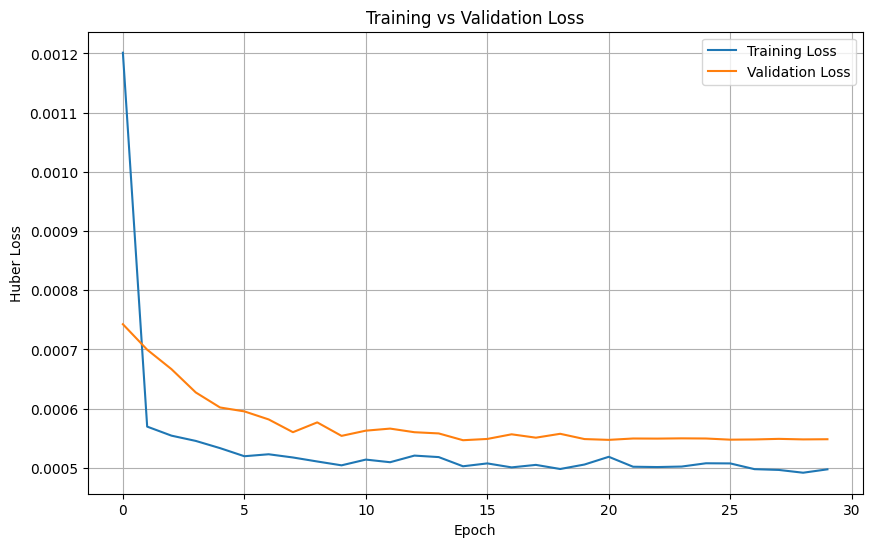

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(track_train, label="Training Loss")
plt.plot(track_val, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------------------------------------------
# ---------------------------------------------------------------------------------------------

## LSTM Performance Evaluation 

### Evaluating On Test Data

In [13]:
# --- restore best weights (if not already done) ---
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

# --- get predictions on the held-out test set ---
preds, truths = [], []
with torch.no_grad():
    for xb, yb in test_loader:              # <- use the DataLoader
        xb = xb.to(device)
        out = model(xb).squeeze(1)          # [batch] in log-return space
        preds.append(out.cpu().numpy())
        truths.append(yb.numpy().squeeze(1))

y_test_pred = np.concatenate(preds)         # predicted log returns
y_test_true = np.concatenate(truths)        # true log returns

# --- align dates for the test window ---
test_start_raw = seq_length + split_index
test_dates = df.index[test_start_raw : test_start_raw + len(y_test_true)]

# get last-day closes (for compounding into prices)
last_closes = df["Close"].shift(1).iloc[test_start_raw : test_start_raw + len(y_test_true)].values

# predicted / actual implied prices
real_pred = last_closes * np.exp(y_test_pred)   # exp(logret) = multiplier
real_BTC  = last_closes * np.exp(y_test_true)

### Predicted v Actual BTC Price

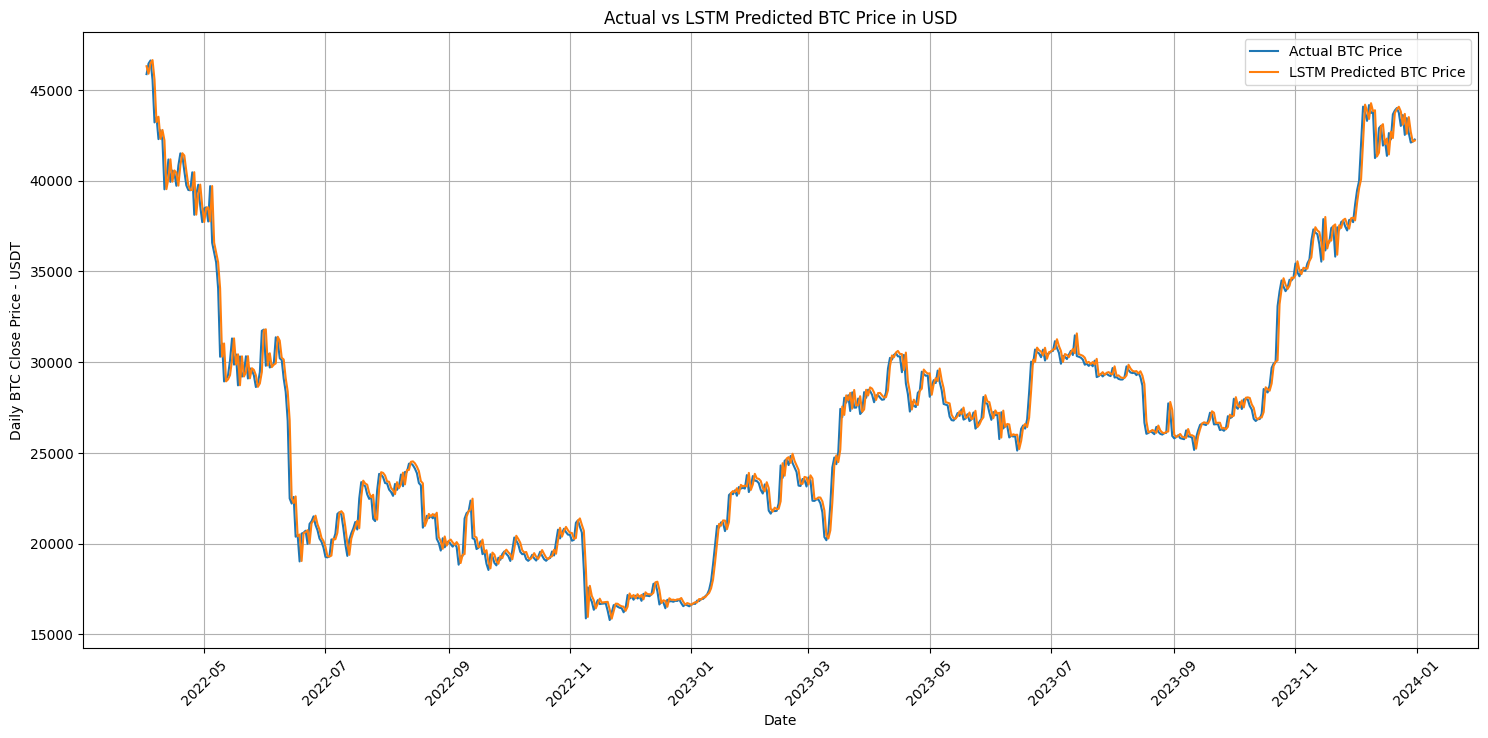

In [14]:
# --- plot ---
plt.figure(figsize=(18, 8))
plt.plot(test_dates, real_BTC,  label="Actual BTC Price")
plt.plot(test_dates, real_pred, label="LSTM Predicted BTC Price")
plt.xlabel("Date")
plt.ylabel("Daily BTC Close Price - USDT")
plt.title("Actual vs LSTM Predicted BTC Price in USD")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

### Econometric Analysis

In [15]:
# --- metrics ---
btc_mean = real_BTC.mean()
NRMSE = (root_mean_squared_error(real_BTC, real_pred) / btc_mean) * 100
NMAE  = (mean_absolute_error(real_BTC, real_pred) / btc_mean) * 100
r2    = r2_score(real_BTC, real_pred)

print(f"NRMSE: {NRMSE:.4f}%")
print(f"NMAE:  {NMAE:.4f}%")
print(f"R-Squared:   {r2:.4f}")

NRMSE: 2.7875%
NMAE:  1.8600%
R-Squared:   0.9892


In [16]:
rmse_ret = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae_ret  = mean_absolute_error(y_test_true, y_test_pred)
corr_ret = np.corrcoef(y_test_true, y_test_pred)[0,1]
hit_rate = np.mean(np.sign(y_test_true) == np.sign(y_test_pred))

print(f"Return RMSE: {rmse_ret:.6f}")
print(f"Return MAE : {mae_ret:.6f}")
print(f"Return Corr: {corr_ret:.3f}")
print(f"Hit rate   : {hit_rate:.3%}")

Return RMSE: 0.027926
Return MAE : 0.018699
Return Corr: 0.095
Hit rate   : 47.731%


In [17]:
naive_rmse = np.sqrt(mean_squared_error(y_test_true, np.zeros_like(y_test_true)))
naive_mae  = mean_absolute_error(y_test_true, np.zeros_like(y_test_true))
print(f"Naïve (r̂=0) RMSE: {naive_rmse:.6f} | MAE: {naive_mae:.6f}")

Naïve (r̂=0) RMSE: 0.027796 | MAE: 0.018178


# ---------------------------------------------------------------------------------------------
# ---------------------------------------------------------------------------------------------

## Algorithmic Trading Module

In [18]:
import backtrader as bt
import datetime

### Fetching OHLCV, Lookback Features and Volatility Data

In [19]:
df_test = df.iloc[seq_length + split_index : seq_length + len(X_array)].copy()
assert len(df_test.index) == len(test_dates)

pred_series = pd.Series(real_pred, index=test_dates)
df_test["lstm_predictions"] = pred_series.shift(1)

# --- features: derivatives of predicted price ---
df_test["first_derivative"]  = df_test["lstm_predictions"].diff(1)
df_test["second_derivative"] = df_test["first_derivative"].diff(1)

# --- confidence measure relative to ATR ---
k_atr = 1.0
edge = (df_test["lstm_predictions"] - df_test["Close"]) / (k_atr * df_test["ATR_14"])
df_test["confidence"] = np.clip(edge.abs(), 0, 3) / 3.0

df_test.dropna(inplace=True)
df_test.index.name = "Date"
df_test = df_test.astype(float)

### BackTrader Trading Engine Setup

In [20]:
class DataFeed(bt.feeds.PandasData):
    lines = ('returns', 'SMA_7', 'SMA_30', 'ATR_14', 'lstm_predictions',
             'first_derivative', 'second_derivative', 'confidence')
    
    params = (
        ('returns', -1),
        ('SMA_7', -1),
        ('SMA_30', -1),
        ('ATR_14', -1),
        ('lstm_predictions', -1),
        ('first_derivative', -1),
        ('second_derivative', -1),
        ('confidence', -1)
    )

data = DataFeed(dataname = df_test)

In [21]:
class MyStrategy(bt.Strategy):
    params = dict(
        # costs & model/bias
        transaction_fees=0.001,
        slippage=0.0005,
        initial_capital=1_000_000,
        bias_alpha=0.067556,        # EWMA smoothing for bias in ATR units
        bias_cap_atr=0.726397,       # cap for EWMA bias (in ATRs)

        # --- asymmetric thresholds (hysteresis) ---
        tau_atr_long=0.315090,       # ENTRY threshold (long) in ATRs
        tau_atr_short=0.564036,      # ENTRY threshold (short) in ATRs (stricter by default)
        exit_tau_factor=0.760413,   # EXIT threshold = cost + tau * exit_tau_factor

        # risk/stop/size
        stop_k=1.551219,             # stop distance in ATRs (used also for trail%)
        risk_frac=0.03,         # risk budget per trade as % of equity - 0.017183
        edge_scale=2.131970,         # scales conviction -> position size
        short_size_penalty=0.826222, # downsize shorts vs longs (direction-aware)

        # trade-frequency taming
        cooldown_bars=0,        # bars to wait after a position CLOSES
        min_hold_bars=2,        # bars we must hold before allowing a flip
        max_hold_bars=15,       # hard cap on bars in a position

        # logging
        save_trade_log='trade_log.csv',
        save_decision_log='decision_log.csv',
    )

    # --------------- setup ---------------
    def __init__(self):
        # data lines
        self.volat = self.datas[0].ATR_14
        self.pred  = self.datas[0].lstm_predictions
        self.conf  = self.datas[0].confidence

        # dynamic bias in ATRs
        self.bias_atr = 0.0
        self.bias_initialised = False
        self.eps = 1e-8

        # state
        self.main_order = None
        self.stop_order = None
        self.holding_bars = 0
        self.cooldown = 0
        self._last_exit_reason = None  # for logging on trade close

        # curves & logs
        self.portfolio_values = []
        self._decision_log = []        # per-bar decision context
        self._trade_log = []           # fills + realized pnl when a trade closes
        self._pending_snapshot = None  # snapshot attached to next order

    def start(self):
        ci = self.broker.getcommissioninfo(self.data)
        commission = getattr(ci.p, "commission", None)
        slip_perc = getattr(getattr(self.broker, "p", None), "slip_perc", None)
        print(f"[START] commission={commission} | slippage_perc={slip_perc}")

    # --------------- main loop ---------------
    def next(self):
        self.portfolio_values.append(self.broker.getvalue())

        # decrement cooldown
        if self.cooldown > 0:
            self.cooldown -= 1

        # if orders outstanding, skip decisioning this bar
        if self.main_order or self.stop_order:
            return

        # track bars in position
        if self.position:
            self.holding_bars += 1
        else:
            self.holding_bars = 0

        # -------- inputs --------
        raw_pred  = float(self.pred[0])
        tod_price = float(self.data.close[0])
        atr       = float(self.volat[0]) if self.volat[0] > 0 else self.eps
        if np.isnan(raw_pred) or np.isnan(atr) or atr <= 0:
            return

        # -------- EWMA bias (in ATRs) --------
        err_atr = (raw_pred - tod_price) / (atr + self.eps)
        if not np.isnan(err_atr):
            if not self.bias_initialised:
                self.bias_atr = err_atr
                self.bias_initialised = True
            else:
                a = float(self.p.bias_alpha)
                self.bias_atr = a * err_atr + (1 - a) * self.bias_atr
            # cap bias so it cannot overpower the signal
            cap = float(self.p.bias_cap_atr)
            self.bias_atr = max(-cap, min(self.bias_atr, cap))

        adj_pred = raw_pred - (self.bias_atr * atr)

        # -------- edge & costs in ATRs --------
        edge_atr = (adj_pred - tod_price) / (atr + self.eps)
        fee  = float(self.p.transaction_fees)
        slip = float(self.p.slippage)
        cost_atr = ((fee + slip) * tod_price) / (atr + self.eps)

        # asymmetric entry thresholds & exit thresholds
        tauL = float(self.p.tau_atr_long)
        tauS = float(self.p.tau_atr_short)
        exit_factor = float(self.p.exit_tau_factor)

        entry_thr_long  = cost_atr + tauL
        entry_thr_short = cost_atr + tauS
        exit_thr_long   = cost_atr + tauL * exit_factor
        exit_thr_short  = cost_atr + tauS * exit_factor

        # -------- dynamic trail (percent of price) --------
        trail_percent = (float(self.p.stop_k) * atr) / max(tod_price, self.eps)
        trail_percent = max(0.001, min(trail_percent, 0.10))  # 0.1% .. 10%

        # -------- base risk & stop distance --------
        risk_cash_base = float(self.p.risk_frac) * self.broker.getvalue()
        stop_distance  = float(self.p.stop_k) * atr
        if stop_distance <= 0:
            return

        # direction-aware conviction (signed)
        edge_strength_signed = max(-1.0, min(edge_atr / float(self.p.edge_scale), 1.0))

        # -------- decision snapshot (for logs) --------
        dt = self.datas[0].datetime.date(0)
        snap = dict(
            dt=str(dt),
            price=tod_price,
            raw_pred=raw_pred,
            adj_pred=adj_pred,
            atr=atr,
            bias_atr=self.bias_atr,
            edge_atr=edge_atr,
            cost_atr=cost_atr,
            entry_thr_long=entry_thr_long,
            entry_thr_short=entry_thr_short,
            exit_thr_long=exit_thr_long,
            exit_thr_short=exit_thr_short,
            trail_percent=trail_percent,
            stop_k=float(self.p.stop_k),
            edge_strength_signed=edge_strength_signed,
            pos_size=float(self.getposition().size),
            cooldown=self.cooldown,
            holding_bars=self.holding_bars,
            equity=float(self.broker.getvalue()),
        )

        # -------------------------------------------------
        # 1) EXIT LOGIC (edge-decay + max-hold) if in pos
        # -------------------------------------------------
        pos = self.getposition()
        if pos.size != 0:
            reason = "in_position_no_exit"

            # long position: exit if edge decays or max-hold hit
            if pos.size > 0:
                if edge_atr <= exit_thr_long and self.holding_bars >= self.p.min_hold_bars:
                    self._last_exit_reason = "edge_exit"
                    self.close()  # market close
                    self.cooldown = int(self.p.cooldown_bars)
                    reason = "edge_exit_triggered"
                elif self.holding_bars >= int(self.p.max_hold_bars):
                    self._last_exit_reason = "max_hold"
                    self.close()
                    self.cooldown = int(self.p.cooldown_bars)
                    reason = "max_hold_triggered"

            # short position: exit if edge decays or max-hold hit
            else:
                if edge_atr >= -exit_thr_short and self.holding_bars >= self.p.min_hold_bars:
                    self._last_exit_reason = "edge_exit"
                    self.close()
                    self.cooldown = int(self.p.cooldown_bars)
                    reason = "edge_exit_triggered"
                elif self.holding_bars >= int(self.p.max_hold_bars):
                    self._last_exit_reason = "max_hold"
                    self.close()
                    self.cooldown = int(self.p.cooldown_bars)
                    reason = "max_hold_triggered"

            self._decision_log.append({**snap, "decision": reason})
            return  # we don’t enter on the same bar we exit

        # -------------------------------------------------
        # 2) ENTRY LOGIC (asymmetric + direction-aware size)
        # -------------------------------------------------
        took_trade = False
        reason = None

        if self.cooldown > 0:
            reason = "skip_cooldown"
        else:
            # LONG side
            if edge_strength_signed > 0:
                risk_cash = risk_cash_base * edge_strength_signed
                size = round(risk_cash / stop_distance, 6)

                if size <= 0:
                    reason = "skip_size_zero"
                elif edge_atr > entry_thr_long:
                    self.main_order = self.buy(size=size, exectype=bt.Order.Market, transmit=False)
                    self.stop_order = self.sell(size=size, exectype=bt.Order.StopTrail,
                                                trailpercent=trail_percent,
                                                parent=self.main_order, transmit=True)
                    self._pending_snapshot = {**snap, "action": "entry_long", "size": size}
                    took_trade = True
                else:
                    reason = "below_entry_thr_long"

            # SHORT side
            elif edge_strength_signed < 0:
                # shrink short size
                risk_cash = risk_cash_base * (-edge_strength_signed) * float(self.p.short_size_penalty)
                size = round(risk_cash / stop_distance, 6)

                if size <= 0:
                    reason = "skip_size_zero"
                elif edge_atr < -entry_thr_short:
                    self.main_order = self.sell(size=size, exectype=bt.Order.Market, transmit=False)
                    self.stop_order = self.buy(size=size, exectype=bt.Order.StopTrail,
                                               trailpercent=trail_percent,
                                               parent=self.main_order, transmit=True)
                    self._pending_snapshot = {**snap, "action": "entry_short", "size": size}
                    took_trade = True
                else:
                    reason = "below_entry_thr_short"

            else:
                reason = "edge_near_zero"

        if took_trade:
            self._decision_log.append({**snap, "decision": self._pending_snapshot["action"]})
        else:
            self._decision_log.append({**snap, "decision": reason})

    # --------------- order/trade notifications ---------------
    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:
            px_exec = float(order.executed.price)
            px_ref  = float(self.data.open[0])  # ref for slippage calc on this bar
            slip_pct = (px_exec - px_ref) / px_ref if px_ref != 0 else np.nan
            comm = float(order.executed.comm)
            side = "BUY" if order.isbuy() else "SELL"

            # Attach snapshot for entries (main_order)
            if self._pending_snapshot and order == self.main_order:
                row = {
                    **self._pending_snapshot,
                    "fill_price": px_exec,
                    "ref_open": px_ref,
                    "slip_pct": slip_pct,
                    "commission": comm,
                }
                self._trade_log.append(row)
                self._pending_snapshot = None

            print(f"{side} EXECUTED | ref_open={px_ref:.2f} exec={px_exec:.2f} "
                  f"| slip={slip_pct*100:.3f}% | size={order.executed.size:.6f} | comm=${comm:.2f}")

            # clear pointers when a child finishes
            if order == self.main_order:
                self.main_order = None
            elif order == self.stop_order:
                self.stop_order = None

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            print(f"ORDER FAILED: {order.getstatusname()}")
            if order == self.main_order:
                self.main_order = None
            elif order == self.stop_order:
                self.stop_order = None

    def notify_trade(self, trade):
        # When a trade closes we get realized PnL here; start cooldown and log reason.
        if trade.isclosed:
            dt = self.datas[0].datetime.date(0)
            reason = self._last_exit_reason if self._last_exit_reason else "trail_stop"
            row = dict(
                dt=str(dt),
                action="trade_closed",
                exit_reason=reason,
                pnl=float(trade.pnl),
                pnlcomm=float(trade.pnlcomm),
                size=float(trade.size),
                price=float(self.data.close[0]),
                equity=float(self.broker.getvalue()),
                cooldown_started=int(self.p.cooldown_bars),
            )
            self._trade_log.append(row)
            self.cooldown = int(self.p.cooldown_bars)
            self._last_exit_reason = None  # reset

    def stop(self):
        # Save logs to disk for analysis
        if self._trade_log and getattr(self.p, "save_trade_log", None):
            pd.DataFrame(self._trade_log).to_csv(self.p.save_trade_log, index=False)
            print(f"[SAVED] trade log -> {self.p.save_trade_log}")
        if self._decision_log and getattr(self.p, "save_decision_log", None):
            pd.DataFrame(self._decision_log).to_csv(self.p.save_decision_log, index=False)
            print(f"[SAVED] decision log -> {self.p.save_decision_log}")

    def log(self, txt):
        dt = self.datas[0].datetime.date(0)
        print(f"{dt.isoformat()} - {txt}")


### BUY & HOLD STRATEGY PERFORMANCE

In [22]:
class BuyHoldAllIn(bt.Strategy):
    def __init__(self):
        self.bought = False
        self.portfolio_values = [] 

    def next(self):
        if not self.position and not self.bought:
            cash = self.broker.getcash()
            size = int(cash / self.data.close[0])
            if size > 0:
                self.buy(size=size)
                self.bought = True
        self.portfolio_values.append(self.broker.getvalue())

In [ ]:
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')           # sharper inline rendering

def run_and_plot(strategy_cls, datafeed, cash=1_000_000, commission=0.001, slippage=0.0005, title=""):
    cerebro = bt.Cerebro()
    cerebro.addstrategy(strategy_cls)
    cerebro.adddata(datafeed)

    cerebro.broker.setcash(cash)
    cerebro.broker.setcommission(commission=commission)

    # percent slippage (applied to open/limit/matched/out orders)
    cerebro.broker.set_slippage_perc(
        perc=slippage, slip_open=True, slip_limit=True, slip_match=True, slip_out=True
    )

    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe',
                        timeframe=bt.TimeFrame.Days, annualize=True, factor=365)
    cerebro.addanalyzer(bt.analyzers.DrawDown,     _name='dd')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer,_name='trades')

    print(f"{title} — Starting Portfolio Value: {cerebro.broker.getvalue():,.2f}")
    results = cerebro.run()
    strat = results[0]

    figs = cerebro.plot(style='candlestick', iplot=False, figscale=2)
    fig = figs[0][0]
    fig.set_size_inches(20, 12, forward=True)
    fig.set_dpi(120)
    fig.tight_layout()
    end_value = cerebro.broker.getvalue()
    pnl = end_value - cash
    print(f"{title} — Final Portfolio Value: {end_value:,.2f}")
    print(f"{title} — Net PnL: {pnl:,.2f}")
    print(f"{title} — Sharpe: {strat.analyzers.sharpe.get_analysis()}")
    print(f"{title} — Drawdown: {strat.analyzers.dd.get_analysis()}")
    print(f"{title} — Trades: {strat.analyzers.trades.get_analysis()}")

    equity = list(getattr(strat, "portfolio_values", []))
    if not equity:
        raise RuntimeError(f"{title}: strategy did not record 'portfolio_values'")
    dates = pd.DatetimeIndex(datafeed.p.dataname.index, name="Date")[:len(equity)]
    return end_value, equity, dates, fig

In [ ]:
%%capture lstm_run_output
# ---- LSTM Run ----
lstm_final, lstm_equity, lstm_dates, lstm_fig = run_and_plot(
    strategy_cls=MyStrategy,
    datafeed=data,
    cash=1_000_000,
    commission=0.001,
    slippage=0.0005,
    title="LSTM Strategy"
)

In [ ]:
# ---- LSTM Run: text output ----
print(lstm_run_output.stdout, end="")

In [ ]:
# ---- LSTM Run: graph ----
from IPython.display import display

display(lstm_fig)
plt.close(lstm_fig)

In [ ]:
%%capture bh_run_output
# ---- B&H Run ----
bh_final, bh_equity, bh_dates, bh_fig = run_and_plot(
    strategy_cls=BuyHoldAllIn,
    datafeed=data,
    cash=1_000_000,
    commission=0.001,
    slippage=0.0005,
    title="Buy & Hold All-In"
)

In [ ]:
# ---- Buy & Hold Run: text output ----
print(bh_run_output.stdout, end="")

In [ ]:
# ---- Buy & Hold Run: graph ----
from IPython.display import display

display(bh_fig)
plt.close(bh_fig)

### Exporting Evaluation Data

In [26]:
# ---- Export equity curves (guard BH presence) ----
eq_lstm = pd.DataFrame({"LSTM": np.asarray(lstm_equity, dtype=float)},
                       index=pd.DatetimeIndex(lstm_dates, name="Date"))

try:
    eq_bh = pd.DataFrame({"BuyHold": np.asarray(bh_equity, dtype=float)},
                         index=pd.DatetimeIndex(bh_dates, name="Date"))
    equity_curves = eq_lstm.join(eq_bh, how="outer").sort_index()
except NameError:
    equity_curves = eq_lstm.copy()

equity_curves.to_csv("equity_curves.csv")
print("[SAVED] equity curves -> equity_curves.csv")

[SAVED] equity curves -> equity_curves.csv


### Grid Search for Best Trading Parameters

In [ ]:
%%capture random_search_output
# -------- Fast RANDOM search for current MyStrategy (threaded for notebooks/Windows) --------
import os, random
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- don't save logs during tuning ---
NOLOG = dict(save_trade_log=None, save_decision_log=None)

# --- WIDER / EASIER RANGES (daily BTC, encourage actual trading) ---
space = dict(
    # bias handling
    bias_alpha         = (0.02, 0.08),     # slower-to-medium adaptation
    bias_cap_atr       = (0.35, 0.95),       # avoid over-dampening the signal

    # asymmetric hysteresis (ENTRY thresholds in ATRs)
    tau_atr_long       = (0.06, 0.40),     # easier long entries
    tau_atr_short      = (0.45, 1.20),     # shorts still stricter

    # EXIT threshold relative to entry tau (bigger => exits easier)
    exit_tau_factor    = (0.6, 0.95),

    # risk/stop/size
    stop_k             = (1.2, 2.2),       # slightly tighter stops -> more trades
    risk_frac          = (0.010, 0.035),   # 1%–5% of equity at risk per trade
    edge_scale         = (1.5, 2.8),       # smaller => more size for same edge
    short_size_penalty = (0.55, 0.85),     # keep shorts smaller by default

    # trade-frequency taming
    cooldown_bars      = (0, 2),           # allow 0 to not choke activity
    min_hold_bars      = (1, 3),
    max_hold_bars      = (6, 16),
)

def sample_params():
    p = {}
    for k, (lo, hi) in space.items():
        if isinstance(lo, int) and isinstance(hi, int):
            p[k] = int(np.random.randint(lo, hi + 1))
        else:
            p[k] = float(np.random.uniform(lo, hi))
    p.update(dict(
        transaction_fees=0.001,
        slippage=0.0005,
    ))
    p.update(NOLOG)
    return p

def _extract_metrics(strat, cash_start):
    sharpe = strat.analyzers.sharpe.get_analysis().get('sharperatio', np.nan)
    dd = strat.analyzers.dd.get_analysis()
    maxdd_pct = float(dd.get('max', {}).get('drawdown', np.nan))
    ta = strat.analyzers.trades.get_analysis()
    total = int(ta.get('total', {}).get('total', 0))
    won = int(ta.get('won', {}).get('total', 0))
    winrate = (won / total) if total > 0 else np.nan
    equity_end = strat.broker.getvalue()
    pnl_total = equity_end - cash_start
    return dict(sharpe=sharpe, maxdd_pct=maxdd_pct,
                trades=total, winrate=winrate,
                pnl_total=pnl_total, equity_end=equity_end)

def run_one(params, cash_start=1_000_000):
    cerebro = bt.Cerebro(stdstats=False)
    cerebro.addstrategy(MyStrategy, **params)
    cerebro.adddata(data)
    cerebro.broker.setcash(cash_start)
    cerebro.broker.setcommission(commission=0.001)
    cerebro.broker.set_slippage_perc(
        perc=0.0005, slip_open=True, slip_limit=True, slip_match=True, slip_out=True
    )
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe',
                        timeframe=bt.TimeFrame.Days, annualize=True)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='dd')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
    results = cerebro.run()
    strat = results[0]
    return {**params, **_extract_metrics(strat, cash_start)}

# -------- search settings --------
N_SAMPLES = 900  # bump up; increase further if it runs comfortably
np.random.seed(42); random.seed(42)
jobs = [sample_params() for _ in range(N_SAMPLES)]

max_workers = max(1, min(8, (os.cpu_count() or 2)))
all_results, errors = [], 0

with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(run_one, p) for p in jobs]
    for i, fut in enumerate(as_completed(futures), 1):
        try:
            res = fut.result()
        except Exception as e:
            # capture the error so you can inspect later
            res = {**jobs[i-1], "sharpe": np.nan, "maxdd_pct": np.nan,
                   "trades": 0, "winrate": np.nan,
                   "pnl_total": np.nan, "equity_end": np.nan,
                   "error": str(e)}
            errors += 1
        all_results.append(res)
        if i % 20 == 0:
            print(f"... {i}/{N_SAMPLES} done (workers={max_workers}) | errors={errors}")

df = pd.DataFrame(all_results)

# --- fill NaNs conservatively for scoring ---
df["sharpe"]    = df["sharpe"].fillna(0.0)       # treat undefined Sharpe as 0
df["maxdd_pct"] = df["maxdd_pct"].fillna(1e9)    # huge penalty if missing
df["trades"]    = df["trades"].fillna(0).astype(int)
df["winrate"]   = df["winrate"].fillna(0.0)
df["pnl_total"] = df["pnl_total"].fillna(0.0)

# --- composite score: balances Sharpe, DD, PnL, win-rate, trade count ---
# (weights chosen to reward robust configs; tweak if needed)
def robust_score(row):
    # clip to keep outliers from dominating
    sharpe = float(np.clip(row["sharpe"], -2.0, 5.0))
    dd_pen = float(row["maxdd_pct"])               # already a % number
    pnl    = float(row["pnl_total"])
    wr     = float(row["winrate"])
    trades = int(row["trades"])

    # normalize-ish terms
    dd_term    = - dd_pen / 5.0                    # every +5% DD knocks ~1 point
    pnl_term   = pnl / 50_000.0                    # 50k pnl ≈ +1 point
    wr_term    = (wr - 0.5) * 2.0                  # 50% -> 0, 60% -> +0.2, 40% -> -0.2
    trades_term= np.log1p(trades) / np.log1p(60)   # ~0..1 for 0..60 trades

    # weights: emphasize Sharpe & DD, then pnl, then winrate and healthy #trades
    return 2.0*sharpe + 1.5*dd_term + 1.2*pnl_term + 0.7*wr_term + 0.6*trades_term

df["score"] = df.apply(robust_score, axis=1)

# quick diagnostics
total = len(df)
with_trades = int((df["trades"] > 0).sum())
print(f"Trials: {total} | >0 trades: {with_trades}")

# robustness gate: require activity
gate = df[df["trades"] >= 20].copy()
if gate.empty:
    gate = df[df["trades"] >= 10].copy()
if gate.empty:
    gate = df.copy()

# final sort: composite score primary, tie-breakers
df_sorted = gate.sort_values(
    by=["score", "sharpe", "maxdd_pct", "pnl_total"],
    ascending=[False, True, True, False]
).reset_index(drop=True)

# persist + show
df_sorted.to_csv("random_search_results.csv", index=False)
print("Saved -> random_search_results.csv (top 10 shown)")

In [ ]:
# ---- Random Search: text output ----
print(random_search_output.stdout, end="")

In [ ]:
# ---- Random Search: parameter score table ----
from IPython.display import display

display(df_sorted.head(10))

### Walk Forward Analysis

In [28]:
# --- reset matplotlib to notebook-friendly inline backend ---
import matplotlib, matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Force inline backend (no external windows)
matplotlib.use('module://matplotlib_inline.backend_inline')
set_matplotlib_formats('retina')

# Turn interactive mode off and close any stragglers
plt.ioff()
plt.close('all')

print("Matplotlib backend:", matplotlib.get_backend())

Matplotlib backend: module://matplotlib_inline.backend_inline


In [ ]:
%%capture wf_run_output
# =======================
# Walk-Forward Analysis — richer folds (monthly step, rolling/expanding)
# =======================
import backtrader as bt
import warnings, os, random
warnings.filterwarnings("ignore")

NOLOG = dict(save_trade_log=None, save_decision_log=None)

SPACE = dict(
    bias_alpha         = (0.02, 0.08),
    bias_cap_atr       = (0.4, 1.0),
    tau_atr_long       = (0.08, 0.50),
    tau_atr_short      = (0.50, 1.40),
    exit_tau_factor    = (0.55, 0.95),
    stop_k             = (1.2, 2.4),
    risk_frac          = (0.010, 0.035),
    edge_scale         = (1.6, 3.0),
    short_size_penalty = (0.55, 0.90),
    cooldown_bars      = (0, 3),
    min_hold_bars      = (1, 3),
    max_hold_bars      = (8, 18),
)

def _sample_params():
    p = {}
    for k, (lo, hi) in SPACE.items():
        if isinstance(lo, int) and isinstance(hi, int):
            p[k] = int(np.random.randint(lo, hi + 1))
        else:
            p[k] = float(np.random.uniform(lo, hi))
    p.update(dict(transaction_fees=0.001, slippage=0.0005))
    p.update(NOLOG)
    return p

def _extract_metrics(strat, cash0):
    sharpe = strat.analyzers.sharpe.get_analysis().get('sharperatio', np.nan)
    dd     = strat.analyzers.dd.get_analysis()
    maxdd  = float(dd.get('max', {}).get('drawdown', np.nan))
    ta     = strat.analyzers.trades.get_analysis()
    trades = int(ta.get('total', {}).get('total', 0))
    win    = int(ta.get('won', {}).get('total', 0))
    winrt  = win / trades if trades > 0 else np.nan
    eq_end = strat.broker.getvalue()
    pnl    = eq_end - cash0
    return dict(sharpe=sharpe, maxdd_pct=maxdd, trades=trades, winrate=winrt,
                pnl_total=pnl, equity_end=eq_end)

def _score(metrics):
    s = np.nan_to_num(metrics['sharpe'], nan=-1.0)
    s = np.clip(s, -1, 3)
    dd = np.nan_to_num(metrics['maxdd_pct'], nan=10.0)
    pnl_m = metrics['pnl_total'] / 1_000_000.0
    tr = metrics['trades']
    return 1.0*s - 0.10*dd + 0.50*pnl_m + 0.01*max(0, tr - 20)

def _make_slice_feed(bt_feed, start, end):
    df_all = bt_feed.p.dataname
    df = df_all.loc[start:end].copy()
    DataCls = bt_feed.__class__
    return DataCls(dataname=df)

def _run_bt(params, feed, cash0=1_000_000):
    cerebro = bt.Cerebro(stdstats=False)
    cerebro.addstrategy(MyStrategy, **params)
    cerebro.adddata(feed)
    cerebro.broker.setcash(cash0)
    cerebro.broker.setcommission(commission=0.001)
    cerebro.broker.set_slippage_perc(perc=0.0005, slip_open=True, slip_limit=True,
                                     slip_match=True, slip_out=True)
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe',
                        timeframe=bt.TimeFrame.Days, annualize=True, factor=365)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='dd')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
    res = cerebro.run()
    strat = res[0]
    return _extract_metrics(strat, cash0)

def walk_forward(
    bt_feed,
    train_months=3,              # smaller train window
    test_months=1,               # 1-month test
    step_months=1,               # new test every month (overlap)
    mode="rolling",              # "rolling" or "expanding"
    n_samples=50,                # fewer samples per fold to keep speed OK
    seed=42,
    cash0=1_000_000,
):
    """
    Returns a DataFrame with one row per TEST fold. Training is performed
    on the preceding train window (rolling) or from start to test_start-1 (expanding).
    """
    np.random.seed(seed); random.seed(seed)
    df = bt_feed.p.dataname
    dates = pd.DatetimeIndex(df.index)
    start = dates.min().normalize()
    end   = dates.max().normalize()

    folds = []
    eq = cash0

    # first test window start
    first_train_end = start + pd.DateOffset(months=train_months) - pd.DateOffset(days=1)
    test_start = first_train_end + pd.DateOffset(days=1)
    test_end   = (test_start + pd.DateOffset(months=test_months)) - pd.DateOffset(days=1)

    while test_end <= end:
        # pick train window
        if mode == "rolling":
            train_start = test_start - pd.DateOffset(months=train_months)
        elif mode == "expanding":
            train_start = start
        else:
            raise ValueError("mode must be 'rolling' or 'expanding'")
        train_end = test_start - pd.DateOffset(days=1)

        # make feeds
        feed_train = _make_slice_feed(bt_feed, train_start, train_end)
        feed_test  = _make_slice_feed(bt_feed, test_start,  test_end)

        # search best params on train
        best, best_params = None, None
        for _ in range(n_samples):
            p = _sample_params()
            m = _run_bt(p, feed_train, cash0=1_000_000)
            s = _score(m)
            if (best is None) or (s > best):
                best, best_params = s, p

        # test
        m_test = _run_bt(best_params, feed_test, cash0=eq)
        ret = (m_test['equity_end'] / eq) - 1.0
        eq  = m_test['equity_end']

        folds.append(dict(
            train_start=str(train_start.date()), train_end=str(train_end.date()),
            test_start=str(test_start.date()),   test_end=str(test_end.date()),
            params=best_params, score_train=best, **m_test, compound_equity=eq, test_return=ret
        ))

        # advance by step_months
        test_start = test_start + pd.DateOffset(months=step_months)
        test_end   = (test_start + pd.DateOffset(months=test_months)) - pd.DateOffset(days=1)

    return pd.DataFrame(folds)

# --------- RUN richer WFA ----------
wf_results = walk_forward(
    data,
    train_months=3,       # try 3/1 monthly step
    test_months=1,
    step_months=1,
    mode="rolling",       # or "expanding"
    n_samples=40,         # adjust for speed
    seed=42,
    cash0=1_000_000,
)


wf_results.to_csv("walk_forward_results.csv", index=False)

In [ ]:
# ---- Walk-Forward Analysis: text output ----
print(wf_run_output.stdout, end="")

In [ ]:
# ---- Walk-Forward Analysis: metrics ----
from IPython.display import display

display(wf_results.head())
print(f"\nFolds: {len(wf_results)}")
print("Final equity:", f"${wf_results.iloc[-1]['compound_equity']:,.2f}")
print("Mean Sharpe:", np.nanmean(wf_results['sharpe']))
print("Median Sharpe:", np.nanmedian(wf_results['sharpe']))
print("Mean test return per fold:", np.mean(wf_results['test_return']))
print("Total compounded return:", wf_results.iloc[-1]['compound_equity']/1_000_000 - 1)

In [ ]:
# ---- Walk-Forward Analysis: graphs ----
from IPython.display import display
import matplotlib.pyplot as plt

tidx = pd.to_datetime(wf_results['test_end'])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tidx, wf_results['compound_equity'] / 1_000_000.0, marker='o', lw=1.2)
ax.set_title("Walk-Forward: Compounded Equity (× $1M)")
ax.set_ylabel("Equity (millions)"); ax.set_xlabel("Test end")
ax.grid(alpha=0.3); fig.tight_layout()
display(fig); plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(tidx, wf_results['sharpe'], width=20, align='center', label='Sharpe')
ax2 = ax.twinx()
ax2.plot(tidx, wf_results['maxdd_pct'], color='tab:red', marker='x', lw=1.0, label='Max DD (%)')
ax.set_title("Walk-Forward: Sharpe (bars) & Max DD (line)")
ax.set_ylabel("Sharpe"); ax2.set_ylabel("Max DD (%)")
ax.grid(alpha=0.3); fig.tight_layout()
display(fig); plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(tidx, wf_results['test_return'], width=20, color='tab:green', alpha=0.85)
ax.axhline(0, color='k', lw=1)
ax.set_title("Walk-Forward: Test Return per Fold")
ax.set_ylabel("Return"); ax.set_xlabel("Test end")
ax.grid(alpha=0.3); fig.tight_layout()
display(fig); plt.close(fig)

### Monte-Carlo Simulation

Daily returns n = 635 | mean = 0.0007700364799980796 | std = 0.00974643449304851
Block bootstrap — median terminal multiple: 1.5762293182475098


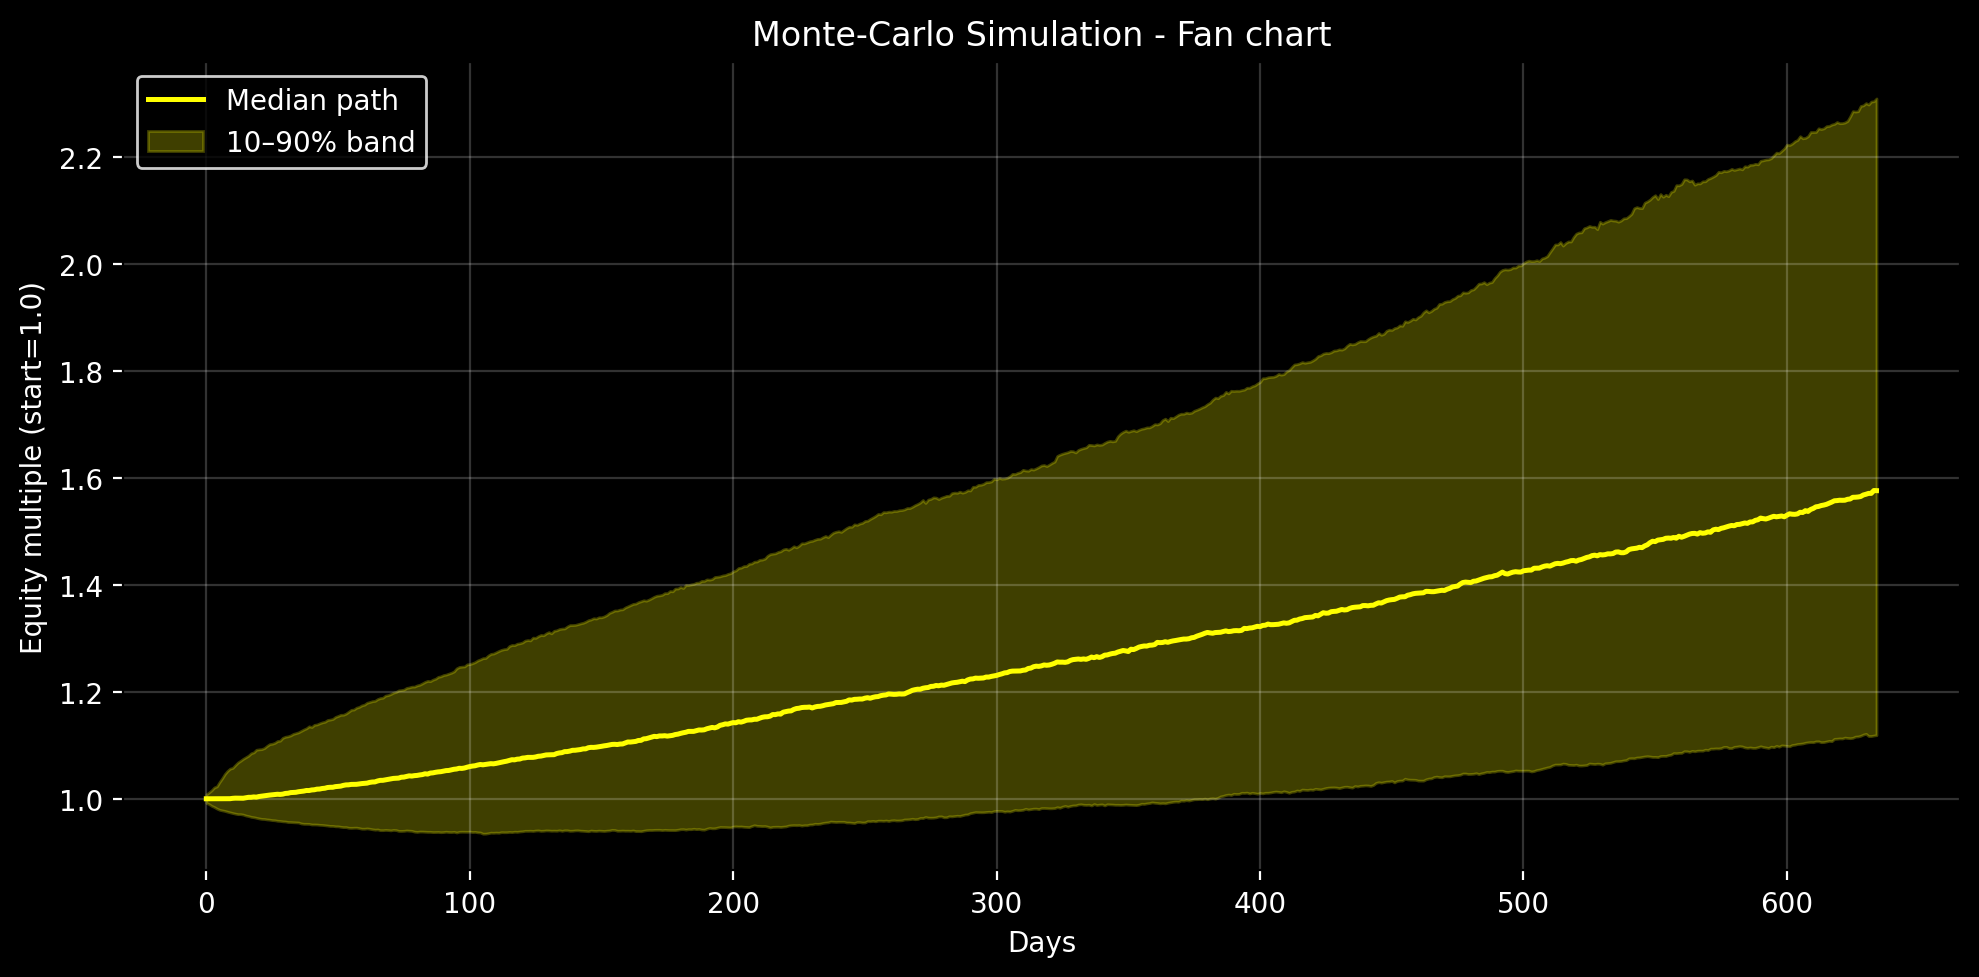

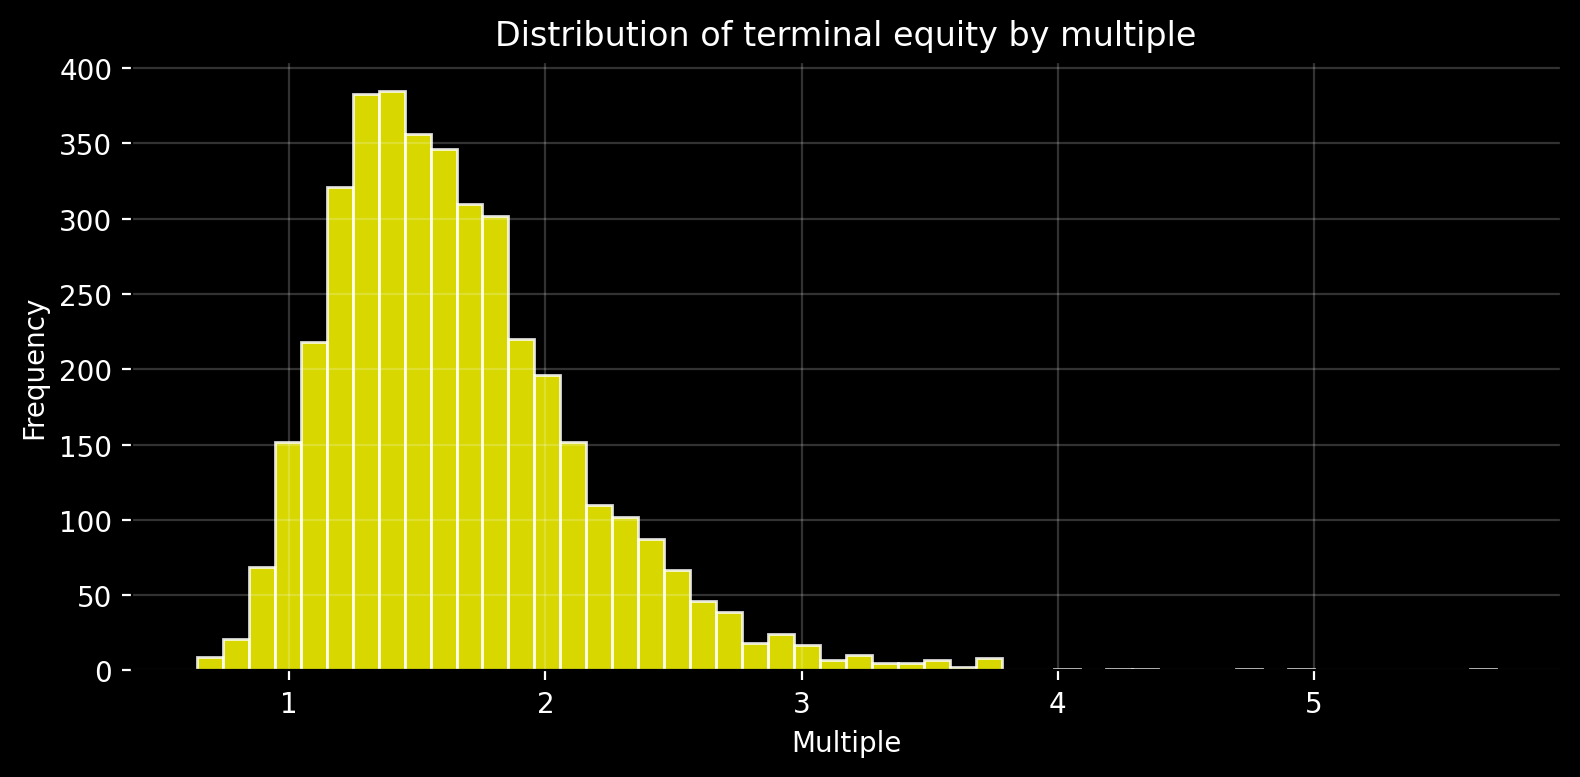

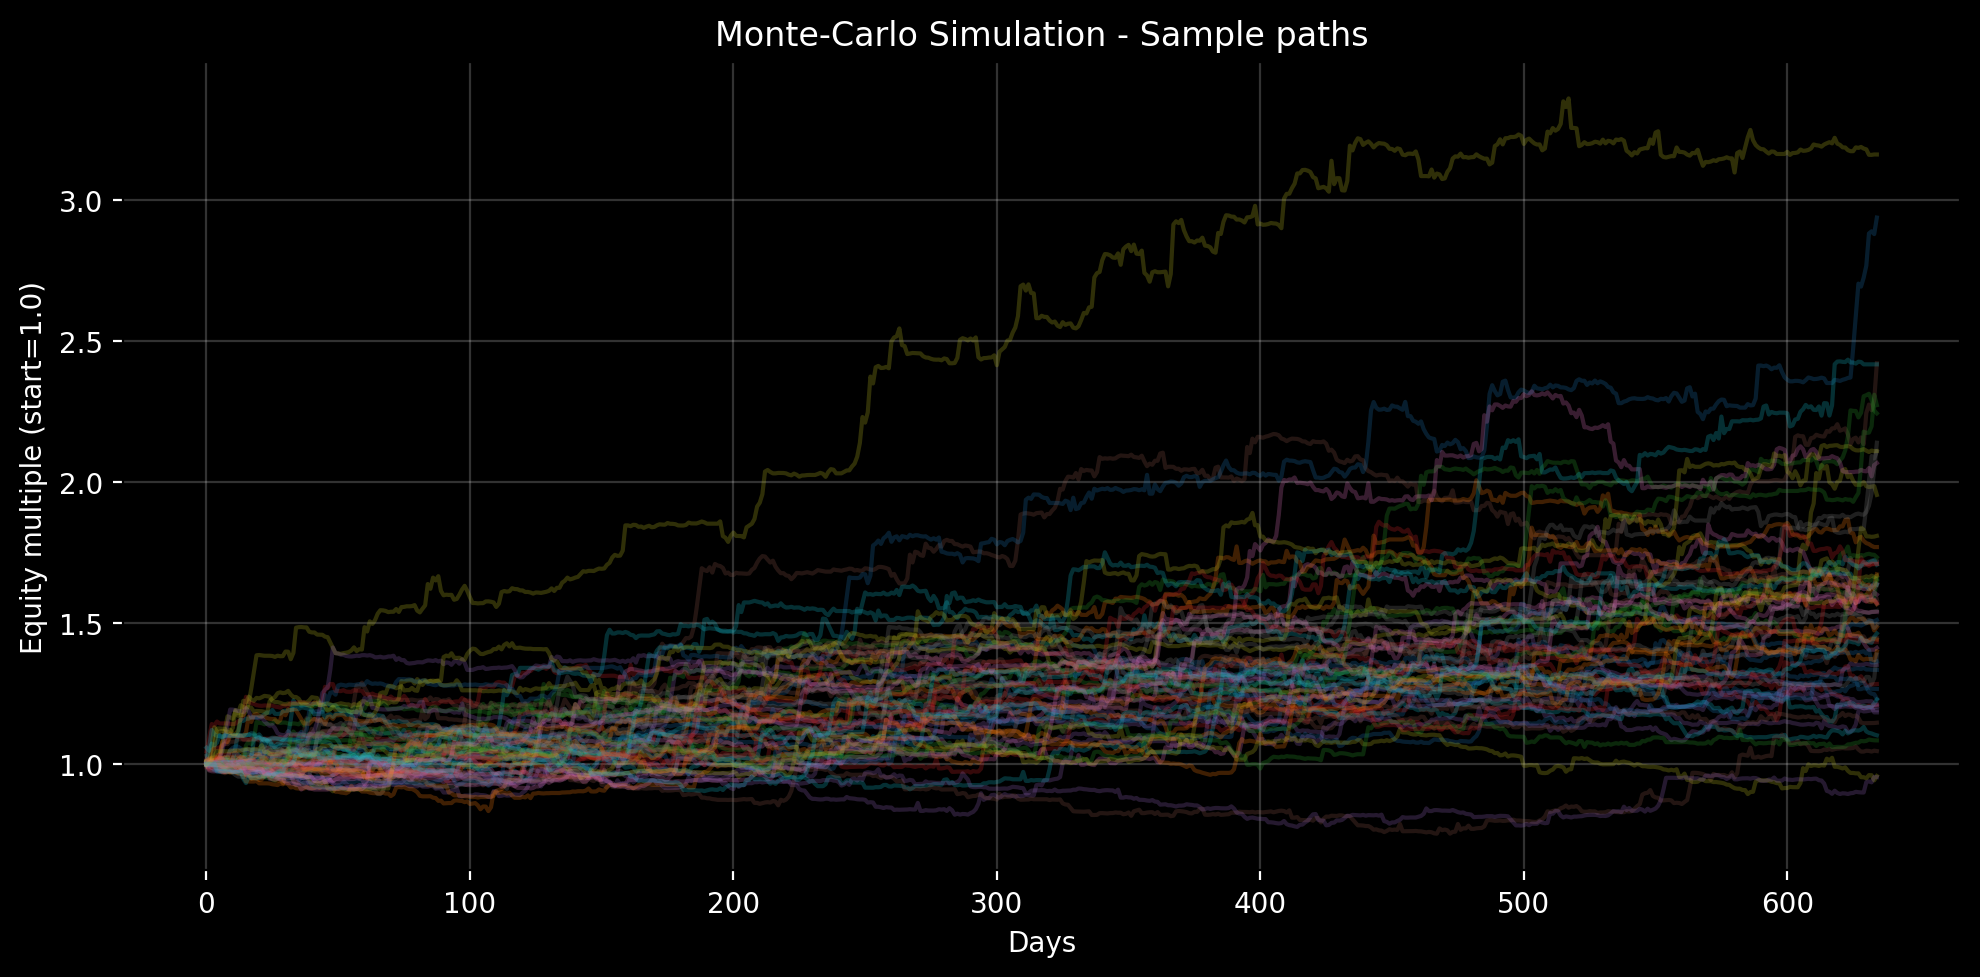

MC median Sharpe: 1.5052782533804472
MC 5th pct terminal multiple: 1.0160677988752242
MC 95th pct worst drawdown: -0.08251891867779178


In [30]:
# =======================
# Monte-Carlo (trades & returns) — full visual suite
# =======================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import backtrader as bt

# ---- 1) get a daily returns series r_t ----
def _get_daily_returns_from_equity():
    # Prefer an equity csv created earlier (e.g., by your plotting helper)
    if os.path.exists("equity_curves.csv"):
        eq = pd.read_csv("equity_curves.csv", parse_dates=["Date"], index_col="Date")
        col = "LSTM" if "LSTM" in eq.columns else eq.columns[0]
        equity = eq[col].dropna().astype(float)
    else:
        # Fallback: run once with your current MyStrategy params already in memory
        cerebro = bt.Cerebro(stdstats=False)
        cerebro.addstrategy(MyStrategy)
        cerebro.adddata(data)
        cerebro.broker.setcash(1_000_000)
        cerebro.broker.setcommission(commission=0.001)
        cerebro.broker.set_slippage_perc(
            perc=0.0005, slip_open=True, slip_limit=True, slip_match=True, slip_out=True
        )
        class EquityGrabber(bt.Analyzer):
            def start(self): self.values=[]
            def next(self):  self.values.append(self.strategy.broker.getvalue())
            def get_analysis(self): return dict(values=self.values)
        cerebro.addanalyzer(EquityGrabber, _name='eq')
        res = cerebro.run()
        vals = res[0].analyzers.eq.get_analysis()['values']
        idx = data.p.dataname.index[:len(vals)]
        equity = pd.Series(vals, index=idx).astype(float)

    ret = equity.pct_change().dropna()
    return ret

r = _get_daily_returns_from_equity().astype(float)
print("Daily returns n =", len(r), "| mean =", r.mean(), "| std =", r.std())

# ---- helpers for stats ----
def max_drawdown_from_equity(eq):
    rollmax = np.maximum.accumulate(eq)
    dd = (eq/rollmax - 1.0)
    return float(dd.min())

def sharpe_from_returns(ret, periods_per_year=365):
    mu = np.mean(ret) * periods_per_year
    sig = np.std(ret) * np.sqrt(periods_per_year)
    return 0.0 if sig == 0 else float(mu / sig)

# ---- optional: trade bootstrap (kept from your version) ----
def trade_bootstrap(n_paths=5000):
    if not os.path.exists("trade_log.csv"):
        print("trade_log.csv not found; skipping trade-bootstrap.")
        return None
    trades = pd.read_csv("trade_log.csv")
    eq_mean = trades.get("equity", pd.Series([1_000_000]*len(trades))).mean()
    trade_r = trades.get("pnlcomm", trades.get("pnl", pd.Series(0))).values / eq_mean
    n = len(trade_r)
    paths = []
    for _ in range(n_paths):
        sample = np.random.choice(trade_r, size=n, replace=True)
        eq = (1+sample).cumprod()
        paths.append(eq[-1])
    paths = np.array(paths)
    print("Trade bootstrap — median multiple:", np.median(paths))
    return paths

# ---- B) Block bootstrap on daily returns ----
def block_bootstrap_paths(ret, horizon=None, block=5, n_paths=2000, seed=42):
    rng = np.random.default_rng(seed)
    ret = np.asarray(ret, float)
    if horizon is None:
        horizon = len(ret)
    paths = np.zeros((n_paths, horizon), dtype=float)
    n_blocks = int(np.ceil(horizon/block))
    for i in range(n_paths):
        seq = []
        for _ in range(n_blocks):
            start = rng.integers(0, len(ret) - block + 1)
            seq.extend(ret[start:start+block])
        seq = np.array(seq[:horizon], float)
        paths[i] = (1.0 + seq).cumprod()
    return paths

# ---- run the Monte-Carlo ----
N_PATHS = 4000
BLOCK   = 5
paths = block_bootstrap_paths(r, horizon=len(r), block=BLOCK, n_paths=N_PATHS, seed=42)
final_mult = paths[:, -1]
print("Block bootstrap — median terminal multiple:", np.median(final_mult))

# ---- fan chart (median + 10–90%) ----
fig, ax = plt.subplots(figsize=(10, 5), facecolor="black")
ax.set_facecolor("black")
q10, q50, q90 = np.percentile(paths, [10, 50, 90], axis=0)
ax.plot(q50, color="yellow", label='Median path', lw=1.8)
ax.fill_between(np.arange(len(q10)), q10, q90, color="yellow", alpha=0.25, label='10–90% band')
ax.set_title("Monte-Carlo Simulation - Fan chart", color="white")
ax.set_xlabel("Days", color="white"); ax.set_ylabel("Equity multiple (start=1.0)", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="black", edgecolor="white", labelcolor="white")
ax.grid(alpha=0.2, color="white")
fig.tight_layout(); plt.show()

# ---- histogram of terminal multiples ----
fig, ax = plt.subplots(figsize=(8, 4), facecolor="black")
ax.set_facecolor("black")
ax.hist(final_mult, bins=50, alpha=0.85, color="yellow", edgecolor="white")
ax.set_title("Distribution of terminal equity by multiple", color="white")
ax.set_xlabel("Multiple", color="white"); ax.set_ylabel("Frequency", color="white")
ax.tick_params(colors="white")
ax.grid(alpha=0.2, color="white")
fig.tight_layout(); plt.show()

# ---- spaghetti plot: show a handful of raw sample paths ----
fig, ax = plt.subplots(figsize=(10, 5), facecolor="black")
ax.set_facecolor("black")
k = min(60, paths.shape[0])  # plot up to 60 paths for legibility
idx = np.random.default_rng(123).choice(paths.shape[0], size=k, replace=False)
for i in idx:
    ax.plot(paths[i], alpha=0.25)  # default colors, good contrast on black
ax.set_title("Monte-Carlo Simulation - Sample paths", color="white")
ax.set_xlabel("Days", color="white"); ax.set_ylabel("Equity multiple (start=1.0)", color="white")
ax.tick_params(colors="white")
ax.grid(alpha=0.2, color="white")
fig.tight_layout(); plt.show()

# ---- summary stats over MC paths ----
ddist = []
sdist = []
for i in range(paths.shape[0]):
    eq = paths[i]
    ddist.append(max_drawdown_from_equity(eq))
    # convert equity path to returns for Sharpe on that simulated path
    sdist.append(sharpe_from_returns(np.diff(eq)/eq[:-1], periods_per_year=365))

print("MC median Sharpe:", np.median(sdist))
print("MC 5th pct terminal multiple:", np.percentile(final_mult, 5))
print("MC 95th pct worst drawdown:", np.percentile(ddist, 95))